In [1]:
from pipeline_functions import *
import torch
import snntorch.spikeplot as splt
import matplotlib.pyplot as plt

Raw data shape: (32, 117120)
(8, 307, 1800)


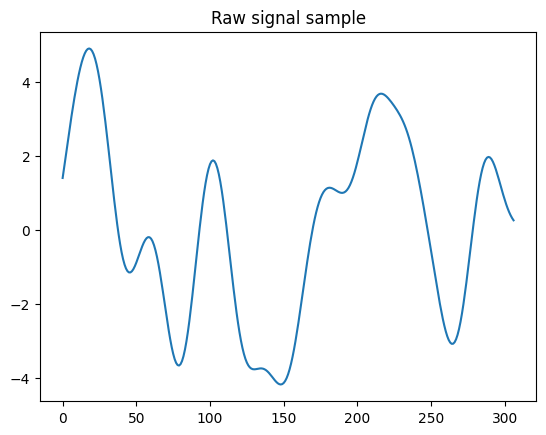

X shape: (1800, 8, 307)
Shape after feature extraction: (360, 8, 28)


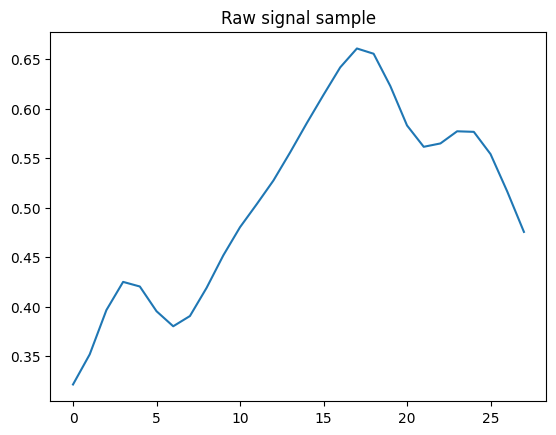

(360, 28, 8)


In [2]:
file_path = f"C:/Users/crims/Desktop/Senior Design Code/datasets/Won2022_BIDS/.mat_files/s01.mat"
# preprocessing
X, y = fn_preprocess.preprocess_testing(file_path, use_training=True)
print(X.shape)

plt.plot(X[0, :, 0])  # trial 0, channel 0
plt.title("Raw signal sample")
plt.show()

# feature extraction
X_fe, y_fe = fn_feature_extraction.extractFeatures(X, y, k=5, factor=6)

plt.plot(X_fe[0, 0, :])  # trial 0, channel 0
plt.title("Raw signal sample")
plt.show()

X_encoded = delta_encoding.delta_encode(X_fe, threshold=0.012) #spike encoding to implement
print(X_encoded.shape)


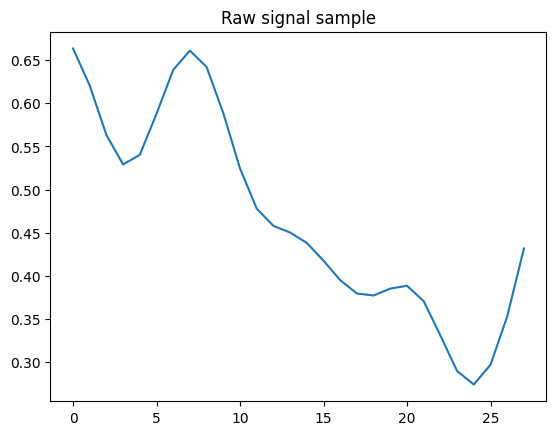

(360, 28, 8)
[ 1 -1 -1 -1  1  1  1  1 -1 -1 -1 -1 -1  0 -1 -1 -1 -1  0  0  0 -1 -1 -1
 -1  1  1  1]


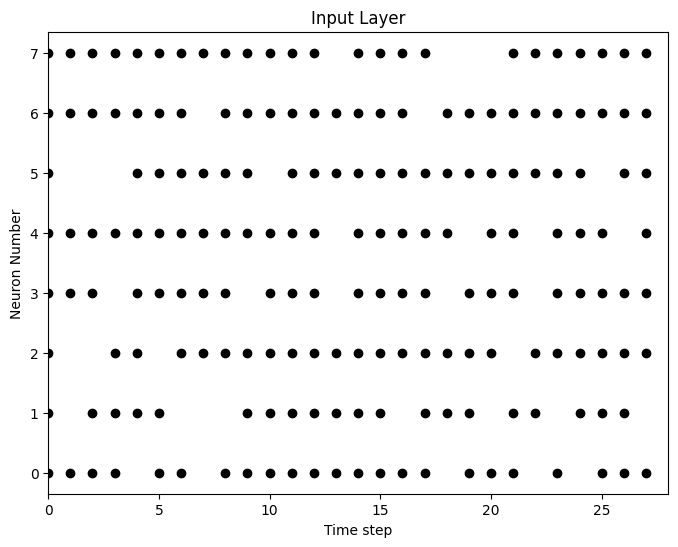

In [3]:
plt.plot(X_fe[0, 7, :])  # trial 0, channel 0
plt.title("Raw signal sample")
plt.show()

X_encoded = delta_encoding.delta_encode(X_fe, threshold=0.011) #spike encoding to implement
print(X_encoded.shape)
# Create fig, ax
fig = plt.figure(facecolor="w", figsize=(8, 6))
ax = fig.add_subplot(111)

print(X_encoded[0, :, 7])
trial_spikes = torch.from_numpy(X_encoded[0, :, :])

# Raster plot of delta converted data
splt.raster(trial_spikes, ax, c="black")

plt.title("Input Layer")
plt.xlabel("Time step")
plt.ylabel("Neuron Number")
plt.xlim(0, X_encoded.shape[1])
plt.show()


In [7]:

# create module
snn = SNNModule.createSNN(8, [256, 128], betas=[0.95, 0.95, 0.95], thresholds=[1, 1, 1])

# load in weights
weights_path = 'C:/Users/crims/Desktop/Senior Design Code/VirtualKeyboard/model_weights/snn_weights_2_window937_fs10_spkreg.pth'
weights = torch.load(weights_path, weights_only=True)
snn.load_state_dict(weights)

snn.eval()

# separate X into individual character signals instead of one big dataset
for i in range(len(X_encoded)//12//3):
    start_idx = i*12*(15//5)
    end_idx = start_idx + 12*(15//5)
    X_char = X_encoded[start_idx:end_idx]
    X_char = torch.from_numpy(X_char).float()
    y_char = y_fe[start_idx:end_idx].astype(int)

    print(X_char.shape)
    # print(X_char.dtype)
    print(y_char.shape)
    print(y_char)

    #get results of model
    with torch.no_grad():
        spk_results, mem_results = snn(X_char, batch_first=True)
    
    spike_counts = spk_results.sum(dim=0)
    pred = spike_counts.argmax(dim=1)
    print(pred)

    # select character based on results
    letter, row_idx, col_idx, row_total, col_total = Characterselection.p300_speller_cycle(spk_results, y_char)
    print(row_total)
    print(col_total)

    print(letter)

torch.Size([36, 28, 8])
(36,)
[ 2  6  7 12  8  4 10  1 11  3  5  9 12  5  6  1  3  9  8 10  4 11  7  2
 11  3  1  6  8  2  7  4 12  9  5 10]
tensor([1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1,
        1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0])
[637. 457. 517. 391. 379. 355.]
[485. 455. 521. 299. 479. 497.]
C
torch.Size([36, 28, 8])
(36,)
[10  6  7  2  3  4  1  9 12 11  8  5 11 12  3  1  6  9  5  7  4  8 10  2
  2  6  3  7 12  8  1  9 11 10  4  5]
tensor([0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0,
        0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1])
[397. 397. 445. 475. 481. 433.]
[437. 419. 443. 365. 473. 491.]
4
torch.Size([36, 28, 8])
(36,)
[ 4  5  3  7  6 12  8  1 11  9 10  2  3 11  9  7 12 10  1  8  5  6  4  2
 12  6  9  2  3  1  8  7  4 11  5 10]
tensor([1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0,
        1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1])
[519. 387. 501. 381. 417. 435.]
[311. 455. 335. 539. 425. 575.]
F
torc